# Детекция спама в SMS

Датасет: https://www.kaggle.com/datasets/uciml/sms-spam-collection-dataset

Датасет содержит 5572 сообщений. Каждое из них размечено как ham (не спам) либо spam. Метка находится в столбце v1, текст сообщения находится в столбце v2.

## Загрузка данных и первичный осмотр

In [6]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv('/kaggle/input/datasets/organizations/uciml/sms-spam-collection-dataset/spam.csv', encoding='latin-1')

In [7]:
df.head(5)

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   v1          5572 non-null   object
 1   v2          5572 non-null   object
 2   Unnamed: 2  50 non-null     object
 3   Unnamed: 3  12 non-null     object
 4   Unnamed: 4  6 non-null      object
dtypes: object(5)
memory usage: 217.8+ KB


In [9]:
df.shape

(5572, 5)

In [10]:
df['v1'].value_counts()

v1
ham     4825
spam     747
Name: count, dtype: int64

## 1. EDA

### 1. Посмотрим, что хранится в строках с непустыми ячейками в столбце Unnamed: 2

In [11]:
non_empty_2 = df[df['Unnamed: 2'].notna()]
non_empty_2[['v1', 'v2', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4']].head(10)

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
95,spam,Your free ringtone is waiting to be collected....,PO Box 5249,"MK17 92H. 450Ppw 16""",NaN
281,ham,\Wen u miss someone,the person is definitely special for u..... B...,why to miss them,"just Keep-in-touch\"" gdeve.."""
444,ham,\HEY HEY WERETHE MONKEESPEOPLE SAY WE MONKEYAR...,HOWU DOIN? FOUNDURSELF A JOBYET SAUSAGE?LOVE ...,NaN,NaN
671,spam,SMS. ac sun0819 posts HELLO:\You seem cool,"wanted to say hi. HI!!!\"" Stop? Send STOP to ...",NaN,NaN
710,ham,Height of Confidence: All the Aeronautics prof...,"this wont even start........ Datz confidence..""",NaN,NaN
899,spam,Your free ringtone is waiting to be collected....,PO Box 5249,"MK17 92H. 450Ppw 16""",NaN
1038,ham,"Edison has rightly said, \A fool can ask more ...",GN,GE,"GNT:-)"""
1127,ham,"Height of \Oh shit....!!\"" situation: A guy th...",".;-):-D""",NaN,NaN
1266,ham,\Hey sorry I didntgive ya a a bellearlier hunny,just been in bedbut mite go 2 thepub l8tr if u...,NaN,NaN
1384,ham,"Storming msg: Wen u lift d phne, u say \HELLO\...","bt not his girlfrnd... G o o d n i g h t . . .@""",NaN,NaN


В Unnamed столбцах хранится продолжение текста одного сообщения. Оно было разбито на несколько колонок при парсинге CSV. Необходимо склеить эти колонки, чтобы отображалось одно сообщение.

### 2. Посмотрим в скольких строках есть пропуски

In [12]:
df.isnull().sum()

v1               0
v2               0
Unnamed: 2    5522
Unnamed: 3    5560
Unnamed: 4    5566
dtype: int64

в первых двух столбцах пропусков нет, значит обрабатывать пропуски не надо

### 3. Анализ целевой переменной

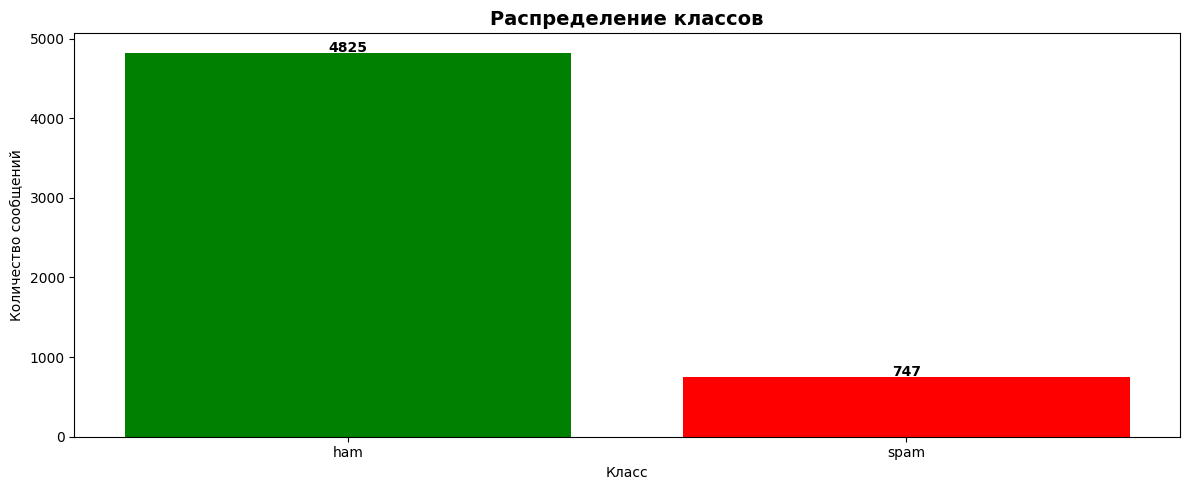

In [13]:
class_counts = df['v1'].value_counts()
class_percentages = df['v1'].value_counts(normalize = True) *100

for label in ['ham', 'spam']:
    count = class_counts.get(label, 0)
    percentage = class_percentages.get(label, 0)

fig, axes = plt.subplots(1, 1, figsize = (12, 5))
axes.bar(class_counts.index, class_counts.values, color=['green', 'red'])
axes.set_title('Распределение классов', fontsize=14, fontweight = 'bold')
axes.set_xlabel('Класс')
axes.set_ylabel('Количество сообщений')
for i, v in enumerate(class_counts.values):
    axes.text(i, v+10, str(v), ha='center', fontweight = 'bold')

plt.tight_layout()
plt.show()

### 4. Посмотрим статистику по длине сообщений

In [14]:
df_clean = pd.DataFrame()
df_clean['label'] = df['v1']
df_clean['text'] = df.apply(lambda row: ' '.join([
    str(row['v2']),
    str(row['Unnamed: 2']) if pd.notna(row['Unnamed: 2']) else '',
    str(row['Unnamed: 3']) if pd.notna(row['Unnamed: 3']) else '',
    str(row['Unnamed: 4']) if pd.notna(row['Unnamed: 4']) else ''
]).strip(), axis=1)

df_clean['text_length'] = df_clean['text'].str.len()
df_clean['word_count'] = df_clean['text'].str.split().str.len()
df_clean['char_count_no_spaces'] = df_clean['text'].str.replace(' ', '').str.len()

# Статистика по классам
print("\nСтатистика по классам:")
for label in ['ham', 'spam']:
    subset = df_clean[df_clean['label'] == label]
    print(f"\n{label.upper()}:")
    print(f"Средняя длина: {subset['text_length'].mean():.1f} символов")
    print(f"Медианная длина: {subset['text_length'].median():.1f} символов")
    print(f"Среднее кол-во слов: {subset['word_count'].mean():.1f}")
    print(f"Макс длина: {subset['text_length'].max()} символов")
    print(f"Мин длина: {subset['text_length'].min()} символов")


Статистика по классам:

HAM:
Средняя длина: 71.6 символов
Медианная длина: 52.0 символов
Среднее кол-во слов: 14.3
Макс длина: 910 символов
Мин длина: 2 символов

SPAM:
Средняя длина: 139.1 символов
Медианная длина: 149.0 символов
Среднее кол-во слов: 23.9
Макс длина: 224 символов
Мин длина: 13 символов


Распределение длины:

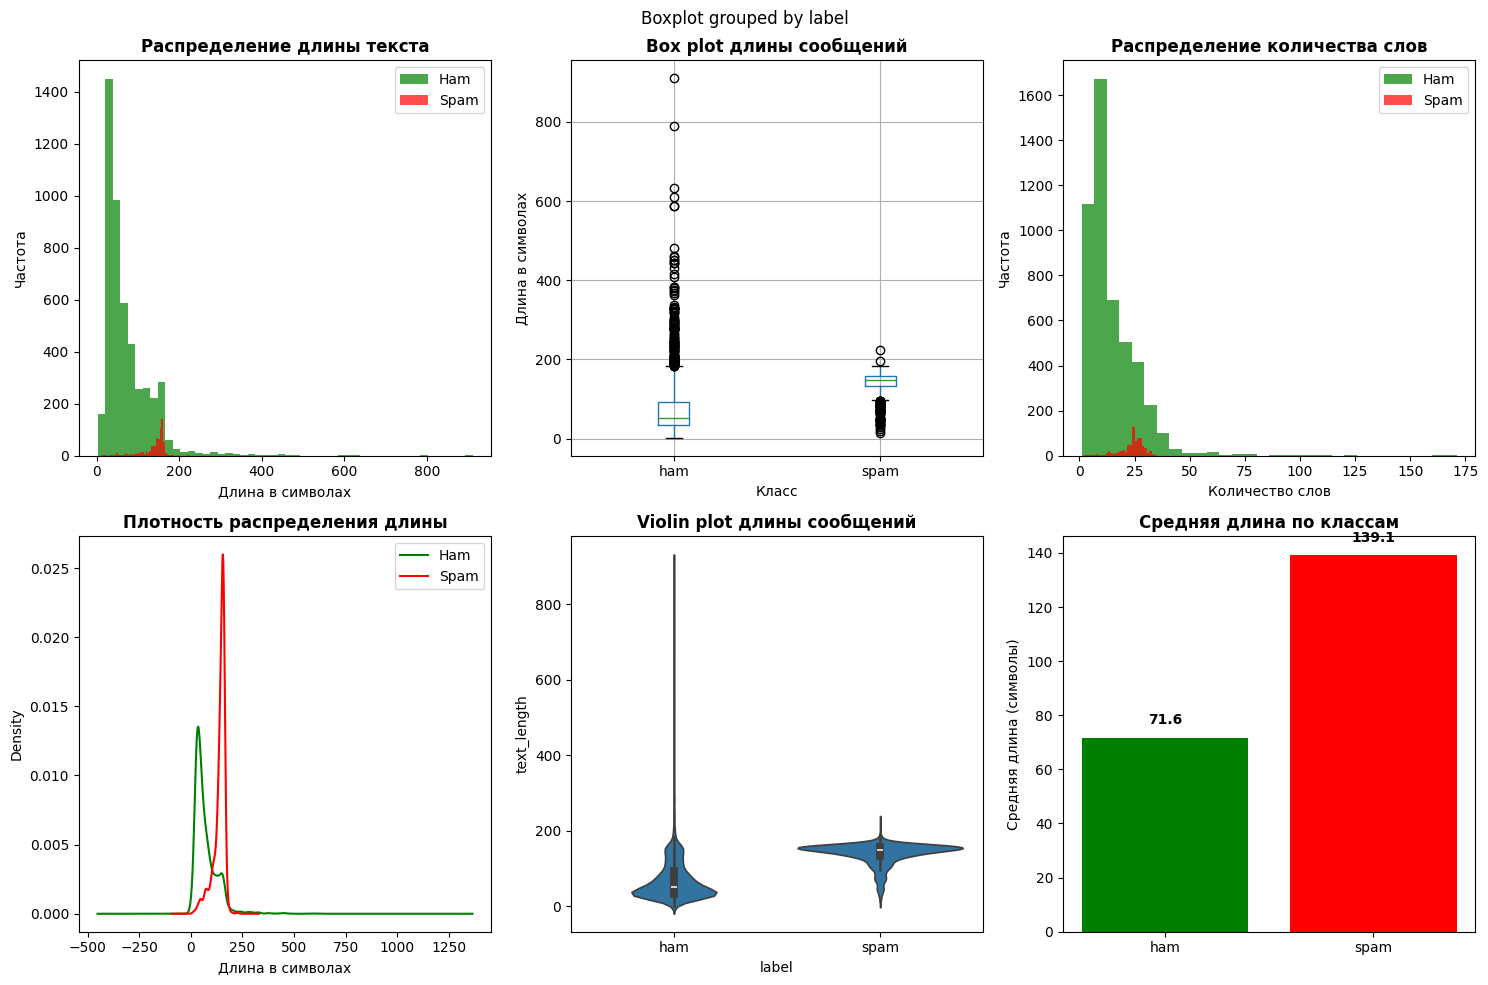

In [15]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# Гистограммы длины текста
axes[0, 0].hist(df_clean[df_clean['label']=='ham']['text_length'], 
                bins=50, alpha=0.7, label='Ham', color='green')
axes[0, 0].hist(df_clean[df_clean['label']=='spam']['text_length'], 
                bins=50, alpha=0.7, label='Spam', color='red')
axes[0, 0].set_title('Распределение длины текста', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Длина в символах')
axes[0, 0].set_ylabel('Частота')
axes[0, 0].legend()

# Box plot длины
df_clean.boxplot(column='text_length', by='label', ax=axes[0, 1])
axes[0, 1].set_title('Box plot длины сообщений', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Класс')
axes[0, 1].set_ylabel('Длина в символах')

# Гистограммы количества слов
axes[0, 2].hist(df_clean[df_clean['label']=='ham']['word_count'], 
                bins=30, alpha=0.7, label='Ham', color='green')
axes[0, 2].hist(df_clean[df_clean['label']=='spam']['word_count'], 
                bins=30, alpha=0.7, label='Spam', color='red')
axes[0, 2].set_title('Распределение количества слов', fontsize=12, fontweight='bold')
axes[0, 2].set_xlabel('Количество слов')
axes[0, 2].set_ylabel('Частота')
axes[0, 2].legend()

# Плотность распределения
df_clean[df_clean['label']=='ham']['text_length'].plot(kind='kde', ax=axes[1, 0], 
                                                       label='Ham', color='green')
df_clean[df_clean['label']=='spam']['text_length'].plot(kind='kde', ax=axes[1, 0], 
                                                         label='Spam', color='red')
axes[1, 0].set_title('Плотность распределения длины', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Длина в символах')
axes[1, 0].legend()

# Зависимость длины от класса
sns.violinplot(data=df_clean, x='label', y='text_length', ax=axes[1, 1])
axes[1, 1].set_title('Violin plot длины сообщений', fontsize=12, fontweight='bold')

# Сравнение средних
means = df_clean.groupby('label')['text_length'].mean()
axes[1, 2].bar(means.index, means.values, color=['green', 'red'])
axes[1, 2].set_title('Средняя длина по классам', fontsize=12, fontweight='bold')
axes[1, 2].set_ylabel('Средняя длина (символы)')
for i, v in enumerate(means.values):
    axes[1, 2].text(i, v + 5, f'{v:.1f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

Из приведенных выше графиков можно сделать вывод о том, что чем больше длина текста, тем скорее сообщение будет спамом.

### 5. Анализ заглавных букв

In [16]:
df_clean['capital_count'] = df_clean['text'].apply(lambda x: sum(1 for c in x if c.isupper()))
df_clean['capital_ratio'] = df_clean['capital_count'] / df_clean['text_length']
df_clean['has_all_caps_word'] = df_clean['text'].apply(
    lambda x: any(word.isupper() and len(word) > 2 for word in x.split())
)

print("Статистика по использованию заглавных букв:")
for label in ['ham', 'spam']:
    subset = df_clean[df_clean['label'] == label]
    print(f"\n{label.upper()}:")
    print(f"  Среднее кол-во заглавных: {subset['capital_count'].mean():.2f}")
    print(f"  Средний процент заглавных: {subset['capital_ratio'].mean()*100:.2f}%")
    print(f"  Сообщения с ЦЕЛЫМИ СЛОВАМИ: {subset['has_all_caps_word'].sum()} "
          f"({subset['has_all_caps_word'].mean()*100:.2f}%)")

Статистика по использованию заглавных букв:

HAM:
  Среднее кол-во заглавных: 4.17
  Средний процент заглавных: 5.94%
  Сообщения с ЦЕЛЫМИ СЛОВАМИ: 374 (7.75%)

SPAM:
  Среднее кол-во заглавных: 15.48
  Средний процент заглавных: 11.06%
  Сообщения с ЦЕЛЫМИ СЛОВАМИ: 553 (74.03%)


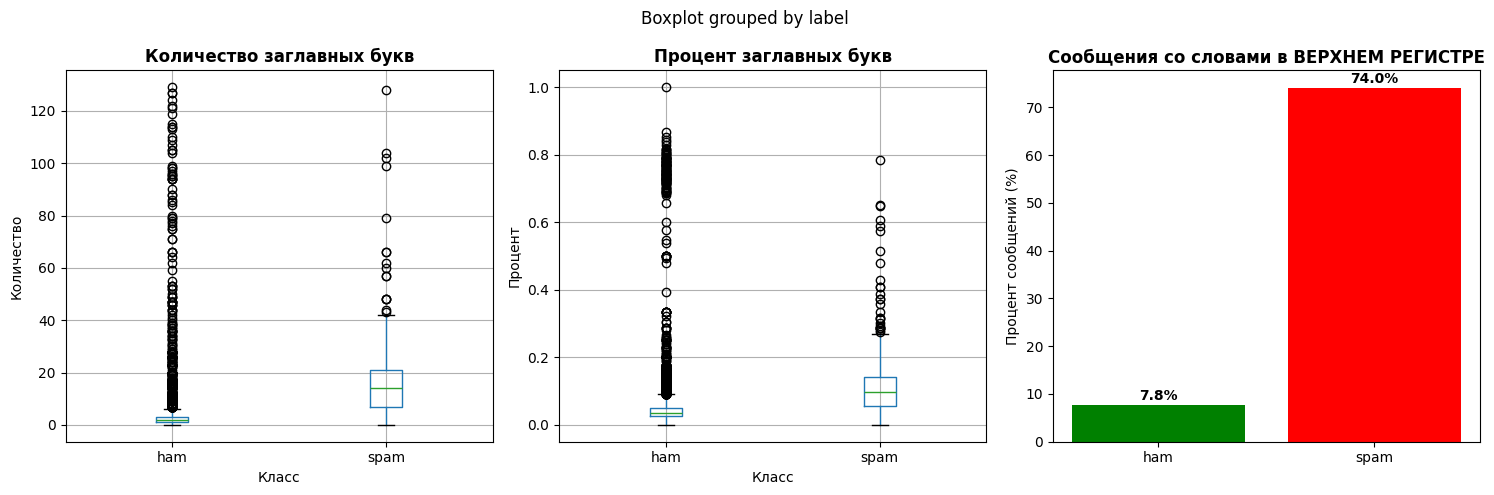

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Количество заглавных
df_clean.boxplot(column='capital_count', by='label', ax=axes[0])
axes[0].set_title('Количество заглавных букв', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Класс')
axes[0].set_ylabel('Количество')

# Процент заглавных
df_clean.boxplot(column='capital_ratio', by='label', ax=axes[1])
axes[1].set_title('Процент заглавных букв', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Класс')
axes[1].set_ylabel('Процент')

# Наличие ЦЕЛЫХ СЛОВ
caps_words_pct = df_clean.groupby('label')['has_all_caps_word'].mean() * 100
axes[2].bar(caps_words_pct.index, caps_words_pct.values, color=['green', 'red'])
axes[2].set_title('Сообщения со словами в ВЕРХНЕМ РЕГИСТРЕ', fontsize=12, fontweight='bold')
axes[2].set_ylabel('Процент сообщений (%)')
for i, v in enumerate(caps_words_pct.values):
    axes[2].text(i, v + 1, f'{v:.1f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

Спам содержит много слов в верхнем регистре.

### 6. Анализ специальных символов и цифр

In [18]:
# Анализ специальных символов
df_clean['number_count'] = df_clean['text'].apply(lambda x: sum(1 for c in x if c.isdigit()))
df_clean['special_char_count'] = df_clean['text'].apply(
    lambda x: sum(1 for c in x if not c.isalnum() and not c.isspace())
)
df_clean['has_url'] = df_clean['text'].str.contains(r'http[s]?://|www\.', case=False, na=False)
df_clean['has_phone'] = df_clean['text'].str.contains(r'\d{3,}[-.]?\d{3,}[-.]?\d{4,}', na=False)

print("Статистика по спецсимволам и цифрам:")
for label in ['ham', 'spam']:
    subset = df_clean[df_clean['label'] == label]
    print(f"\n{label.upper()}:")
    print(f"  Среднее кол-во цифр: {subset['number_count'].mean():.2f}")
    print(f"  Среднее кол-во спецсимволов: {subset['special_char_count'].mean():.2f}")
    print(f"  Содержат URL: {subset['has_url'].sum()} ({subset['has_url'].mean()*100:.2f}%)")
    print(f"  Содержат телефон: {subset['has_phone'].sum()} ({subset['has_phone'].mean()*100:.2f}%)")

Статистика по спецсимволам и цифрам:

HAM:
  Среднее кол-во цифр: 0.31
  Среднее кол-во спецсимволов: 4.07
  Содержат URL: 2 (0.04%)
  Содержат телефон: 1 (0.02%)

SPAM:
  Среднее кол-во цифр: 15.81
  Среднее кол-во спецсимволов: 6.18
  Содержат URL: 106 (14.19%)
  Содержат телефон: 407 (54.48%)


Если сообщение содержит много цифр, спецсимволов, url или телефон, то это скорее всего спам.

### 7. Проведем корреляционный анализ

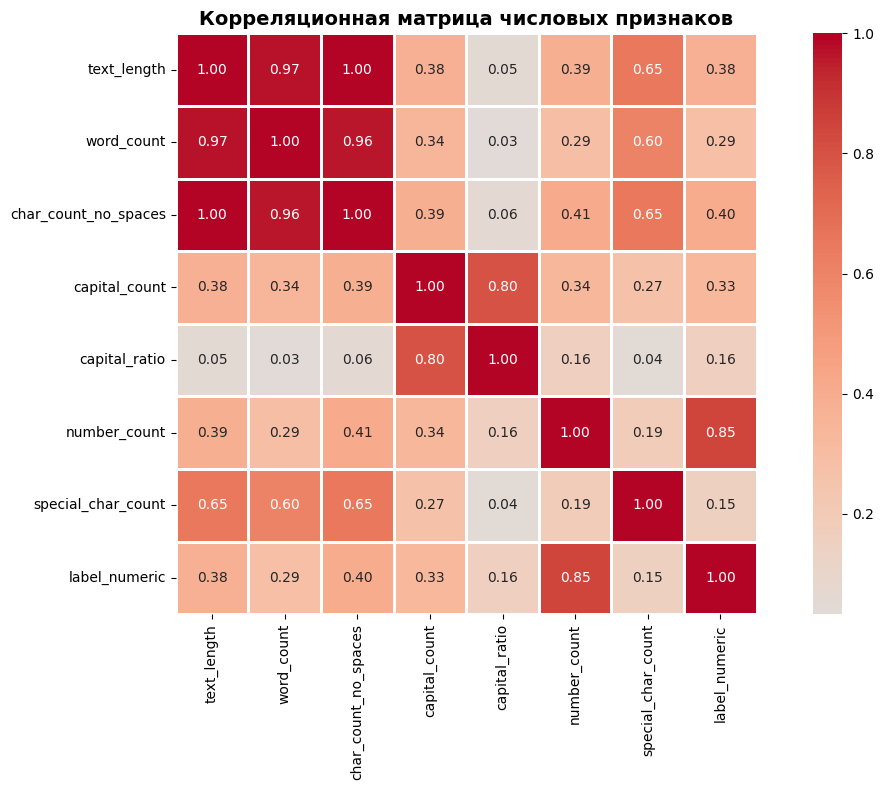


=== КОРРЕЛЯЦИЯ С ЦЕЛЕВОЙ ПЕРЕМЕННОЙ (spam) ===
number_count: 0.845
char_count_no_spaces: 0.404
text_length: 0.383
capital_count: 0.330
word_count: 0.287
capital_ratio: 0.161
special_char_count: 0.151


In [19]:
df_numeric = df_clean.copy()
df_numeric['label_numeric'] = (df_numeric['label'] == 'spam').astype(int)

numeric_cols = ['text_length', 'word_count', 'char_count_no_spaces', 
                'capital_count', 'capital_ratio', 'number_count', 
                'special_char_count', 'label_numeric']

corr_matrix = df_numeric[numeric_cols].corr()

plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, 
            square=True, linewidths=1, fmt='.2f')
plt.title('Корреляционная матрица числовых признаков', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n=== КОРРЕЛЯЦИЯ С ЦЕЛЕВОЙ ПЕРЕМЕННОЙ (spam) ===")
target_corr = corr_matrix['label_numeric'].drop('label_numeric').sort_values(ascending=False)
for feature, corr in target_corr.items():
    print(f"{feature}: {corr:.3f}")

Наибольшая корреляция у целевой переменной с наличием цифр, количеством символов в тексте без пробела, длиной текста, заглавными буквами.

### 8. Анализ повторяющихся сообщений

In [20]:
duplicates = df_clean['text'].duplicated(keep=False)
duplicate_groups = df_clean[duplicates].groupby('text')['label'].agg(['count', 'unique'])

print(f"Всего дубликатов: {duplicates.sum()}")
print(f"Уникальных сообщений с дубликатами: {len(duplicate_groups)}")

Всего дубликатов: 703
Уникальных сообщений с дубликатами: 289


### Вывод по EDA

1) Наибольшая корреляция у целевой переменной с наличием цифр, количеством символов в тексте без пробела, длиной текста, заглавными буквами. Если сообщение содержит много цифр, спецсимволов, url или телефон, то это скорее всего спам.
2) Спам содержит много слов в верхнем регистре.
3) Чем больше длина текста, тем скорее сообщение будет спамом.

## 2. Feature engineering

### To do:
1) Объединить последние колонки в одну.
2) Переименовать столбцы.
3) Сделать дополнительные признаки - text_length, number_count, char_count_no_spaces, capital_count, has_url, has_phone, has_all_caps_word.

### 1. Объединение колонок

In [21]:
def combine_text_columns(row):
    text_parts = [str(row['v2'])]
    
    for col in ['Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4']:
        if pd.notna(row[col]) and str(row[col]).strip():
            clean_part = str(row[col]).strip(' "\'')
            if clean_part:
                text_parts.append(clean_part)
    
    return ' '.join(text_parts)

### 2. Переименование столбцов

In [22]:
df_clean = pd.DataFrame()
df_clean['label'] = df['v1']
df_clean['text'] = df.apply(combine_text_columns, axis=1)

### 3. Сделать дополнительные признаки

In [23]:
import re
def has_url(text):
    url_pattern = r'http[s]?://(?:[a-zA-Z]|[0-9]|[$-_@.&+]|[!*\\(\\),]|(?:%[0-9a-fA-F][0-9a-fA-F]))+|www\.[a-zA-Z0-9.-]+'
    return 1 if re.search(url_pattern, str(text)) else 0

def has_phone(text):
    phone_pattern=r'\b[\d\s\-\(\)\.]{7,}\b'
    digit_pattern = r'\d{5,}'
    return 1 if (re.search(phone_pattern, str(text)) or re.search(digit_pattern, str(text))) else 0

def has_all_caps_word(text):
    words = str(text).split()
    for word in words:
        clean_word = re.sub(r'[^\w]', '', word)
        if len(clean_word) > 2 and clean_word.isupper():
            return 1
    return 0

df_clean['text_length'] = df_clean['text'].str.len()
df_clean['number_count'] = df_clean['text'].apply(lambda x: sum(c.isdigit() for c in str(x)))
df_clean['char_count_no_spaces'] = df_clean['text'].apply(lambda x: len(str(x).replace(' ', '')))
df_clean['capital_count'] = df_clean['text'].apply(lambda x: sum(c.isupper() for c in str(x)))
df_clean['has_url'] = df_clean['text'].apply(has_url)
df_clean['has_phone'] = df_clean['text'].apply(has_phone)
df_clean['has_all_caps_word'] = df_clean['text'].apply(has_all_caps_word)

In [24]:
df_clean.head(5)

,label,text,text_length,number_count,char_count_no_spaces,capital_count,has_url,has_phone,has_all_caps_word
0,ham,"Go until jurong point, crazy.. Available only ...",111,0,92,3,0,0,0
1,ham,Ok lar... Joking wif u oni...,29,0,24,2,0,0,0
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,155,25,128,10,0,1,0
3,ham,U dun say so early hor... U c already then say...,49,0,39,2,0,0,0
4,ham,"Nah I don't think he goes to usf, he lives aro...",61,0,49,2,0,0,0


## 3. Классические ML-модели

### 3.1. Разделение на признаки и целевую переменную

In [25]:
X_text = df_clean['text']
X_features = df_clean[['text_length', 'number_count', 'char_count_no_spaces', 'capital_count', 'has_url', 'has_phone', 'has_all_caps_word']]
y = (df_clean['label'] == 'spam').astype(int)

### 3.2. Создание TF-IDF признаков

In [26]:
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

tfidf = TfidfVectorizer(
    max_features = 5000,
    min_df = 5,
    max_df = 0.7,
    ngram_range = (1, 2),
    stop_words='english'
)

X_tfidf = tfidf.fit_transform(X_text)

Далее объединяем tf-idf с числовыми признаками, преобразуем их

In [27]:
from scipy.sparse import hstack, csr_matrix
X_numeric = csr_matrix(X_features.values)
X_combined = hstack([X_tfidf, X_numeric])

### 3.3. Разделение датасета на train и test

In [28]:
X_train, X_test, y_train, y_test = train_test_split(
    X_combined, y, test_size = 0.2, random_state = 42, stratify = y
)

### 3.4. Базовая модель - Логистическая регрессия


TRAIN:
Accuracy:  0.9879
Precision: 0.9892
Recall:    0.9197
F1-score:  0.9532

TEST:
Accuracy:  0.9803
Precision: 0.9774
Recall:    0.8725
F1-score:  0.9220


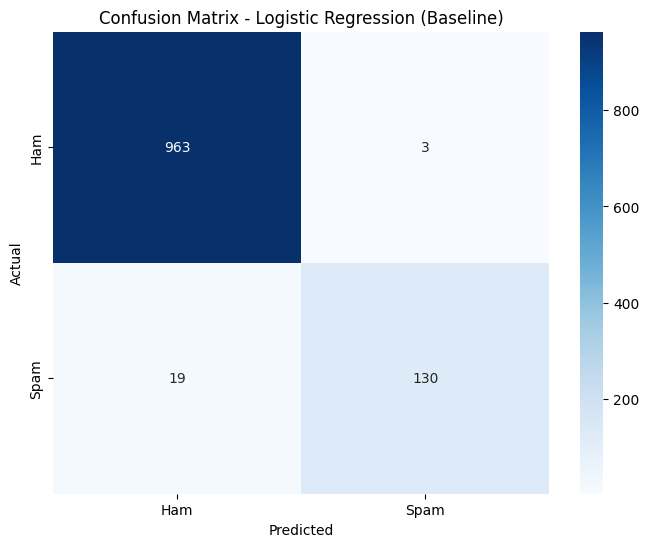

Кросс-валидация
F1 scores: [0.96137339 0.94067797 0.93859649 0.89400922 0.96103896]
Mean F1: 0.9391 (+/- 0.0491)


In [29]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# Создание модели
lr_baseline = LogisticRegression(random_state=42, max_iter=1000)
lr_baseline.fit(X_train, y_train)

# Предсказания
y_pred_train = lr_baseline.predict(X_train)
y_pred_test = lr_baseline.predict(X_test)

# Вывод метрик
def print_metrics(y_true, y_pred, dataset_name):
    print(f"\n{dataset_name}:")
    print(f"Accuracy:  {accuracy_score(y_true, y_pred):.4f}")
    print(f"Precision: {precision_score(y_true, y_pred):.4f}")
    print(f"Recall:    {recall_score(y_true, y_pred):.4f}")
    print(f"F1-score:  {f1_score(y_true, y_pred):.4f}")

print_metrics(y_train, y_pred_train, "TRAIN")
print_metrics(y_test, y_pred_test, "TEST")

# Матрица ошибок
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred_test)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Ham', 'Spam'], 
            yticklabels=['Ham', 'Spam'])
plt.title('Confusion Matrix - Logistic Regression (Baseline)')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

# Кросс-валидация
cv_scores = cross_val_score(lr_baseline, X_train, y_train, cv=5, scoring='f1')
print("Кросс-валидация")
print(f"F1 scores: {cv_scores}")
print(f"Mean F1: {cv_scores.mean():.4f} (+/- {cv_scores.std() * 2:.4f})")

Из матрицы ошибок видно, что модель хорошо определяем не спам и спам (но спам определяет чуть хуже).
Есть небольшое переобучение, но некритичное. Возможно, так произошло потому, что спама у нас меньше, чем не спама, поэтому модель учится распознавать не спам.

### 3.5. Модель 1 - Random Forest с подбором гиперпараметров

In [30]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

rf = RandomForestClassifier(random_state = 42, n_jobs = -1)
param_grid_rf = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'class_weight': ['balanced', None]
}

grid_rf = GridSearchCV(
    rf,
    param_grid_rf,
    cv = 5,
    scoring = 'f1',
    n_jobs = -1,
    verbose = 1
)

grid_rf.fit(X_train, y_train)

print(f"\nЛучшие параметры: {grid_rf.best_params_}")
print(f"Лучший F1 на кросс-валидации: {grid_rf.best_score_:.4f}")

Fitting 5 folds for each of 48 candidates, totalling 240 fits

Лучшие параметры: {'class_weight': 'balanced', 'max_depth': 20, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 100}
Лучший F1 на кросс-валидации: 0.9658


In [31]:
y_pred_rf = grid_rf.predict(X_test)
print(f"Результаты на тестовых данных")
print(f"Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_rf):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_rf):.4f}")
print(f"F1-score: {f1_score(y_test, y_pred_rf):.4f}")

Результаты на тестовых данных
Accuracy: 0.9821
Precision: 0.9574
Recall: 0.9060
F1-score: 0.9310


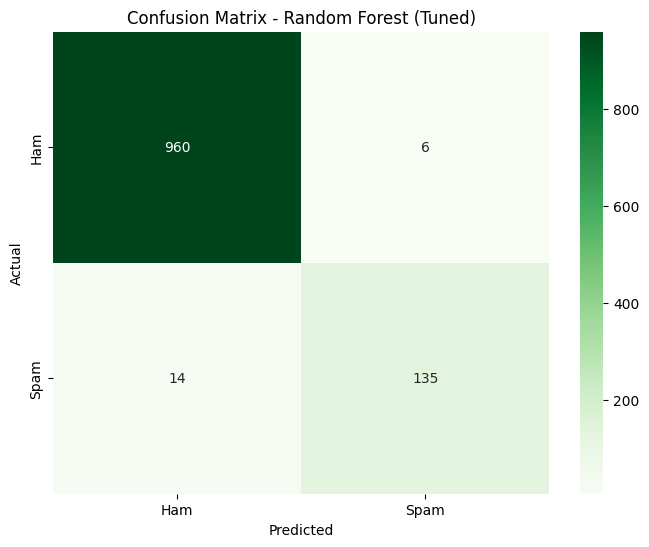

In [32]:
plt.figure(figsize=(8, 6))
cm_rf = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Ham', 'Spam'],
            yticklabels=['Ham', 'Spam'])
plt.title('Confusion Matrix - Random Forest (Tuned)')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

Есть некритичное переобучение. Проверим наиболее важные признаки

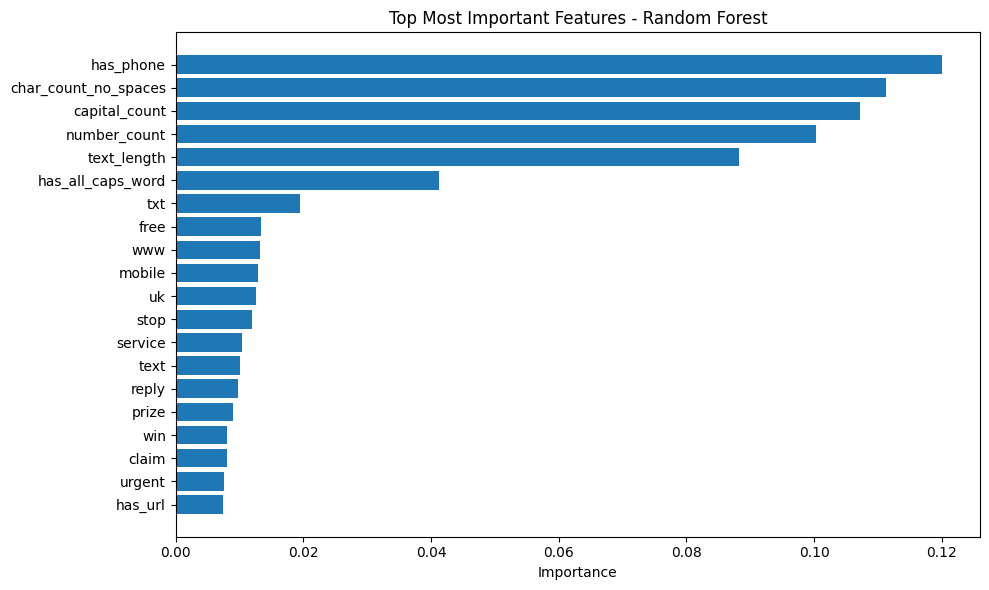

In [33]:
feature_names = tfidf.get_feature_names_out().tolist() + X_features.columns.tolist()
importances = grid_rf.best_estimator_.feature_importances_
indices = np.argsort(importances)[::-1][:20]

plt.figure(figsize=(10, 6))
plt.title('Top Most Important Features - Random Forest')
plt.barh(range(20), importances[indices][::-1])
plt.yticks(range(20), [feature_names[i] for i in indices[::-1]])
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

### 3.6. Модель 2 - Linear Logistic Regression c подбором

In [34]:
from sklearn.linear_model import LogisticRegression

lr_baseline = LogisticRegression(
    random_state=42,
    max_iter=5000,
    tol=1e-3,
)

param_grid_lr = {
    'C': [0.01, 0.1, 1, 10, 100],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear', 'saga'],
    'class_weight': ['balanced', None]
}

grid_lr = GridSearchCV(
    lr_baseline,
    param_grid_lr,
    cv=5,
    scoring='f1',
    n_jobs = -1,
    verbose = 1
)

grid_lr.fit(X_train, y_train)
print(f"Лучший F1 на кросс-валидации: {grid_lr.best_score_:.4f}")

Fitting 5 folds for each of 40 candidates, totalling 200 fits
Лучший F1 на кросс-валидации: 0.9590



Результаты на тестовых данных:
Accuracy:  0.9874
Precision: 0.9927
Recall:    0.9128
F1-score:  0.9510


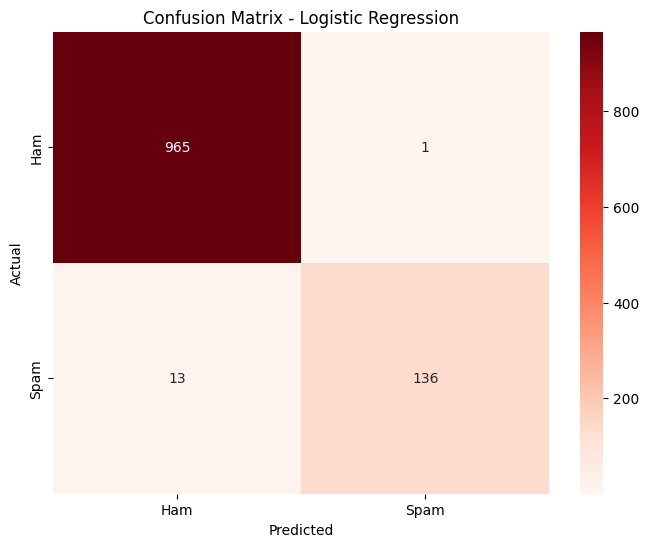

In [35]:
y_pred_lr = grid_lr.predict(X_test)

print(f"\nРезультаты на тестовых данных:")
print(f"Accuracy:  {accuracy_score(y_test, y_pred_lr):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_lr):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_lr):.4f}")
print(f"F1-score:  {f1_score(y_test, y_pred_lr):.4f}")

plt.figure(figsize=(8, 6))
cm_lr = confusion_matrix(y_test, y_pred_lr)
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Reds',
            xticklabels=['Ham', 'Spam'],
            yticklabels=['Ham', 'Spam'])
plt.title('Confusion Matrix - Logistic Regression')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

Модель логистической регрессии хорошо предсказала данные, ее результаты почти идентичны Random Forest

### 3.7. Модель 3 - Ансамбль Gradient Boosting

In [36]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import uniform, randint

gb = GradientBoostingClassifier(random_state = 42)
param_dist_gb = {
    'n_estimators': randint(50, 300),
    'max_depth': randint(3, 10),
    'min_samples_split': randint(2, 10),
    'min_samples_leaf': randint(1, 5),
    'learning_rate': uniform(0.01, 0.3),
    'subsample': uniform(0.6, 0.4)
}

random_gb = RandomizedSearchCV(
    gb,
    param_distributions=param_dist_gb,
    n_iter=30,
    cv=5,
    scoring='f1',
    random_state=42,
    n_jobs=-1,
    verbose=1
)

random_gb.fit(X_train, y_train)
print(f"Лучший F1 на кросс-валидации: {random_gb.best_score_:.4f}")

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Лучший F1 на кросс-валидации: 0.9574



Результаты на тестовых данных:
Accuracy:  0.9812
Precision: 0.9444
Recall:    0.9128
F1-score:  0.9283


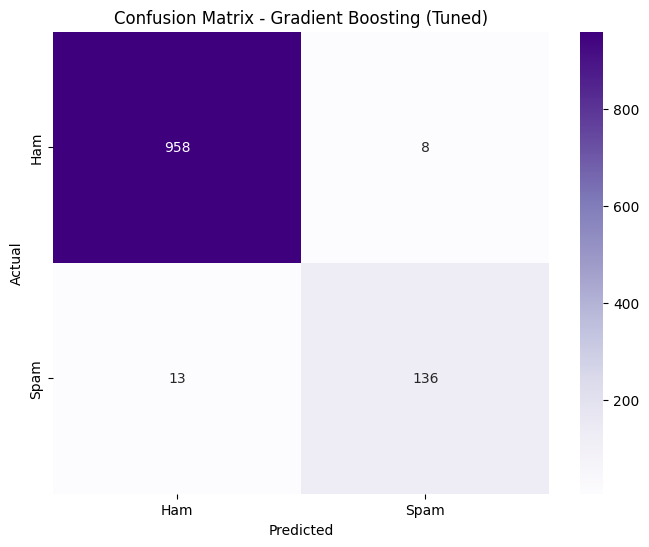

In [37]:
y_pred_gb = random_gb.predict(X_test)
print(f"\nРезультаты на тестовых данных:")
print(f"Accuracy:  {accuracy_score(y_test, y_pred_gb):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_gb):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_gb):.4f}")
print(f"F1-score:  {f1_score(y_test, y_pred_gb):.4f}")

plt.figure(figsize=(8, 6))
cm_gb = confusion_matrix(y_test, y_pred_gb)
sns.heatmap(cm_gb, annot=True, fmt='d', cmap='Purples',
            xticklabels=['Ham', 'Spam'],
            yticklabels=['Ham', 'Spam'])
plt.title('Confusion Matrix - Gradient Boosting (Tuned)')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

Модель Gradient Boosting справилась немного хуже, чем другие модели.

Вывод по обучению моделей. Наилучший результат показала модель Random Forest. Остальные модели справились хорошо, точность почти совпадает с RF.

## 4. Нейронная связь MLP

### 4.1. Подготовка данных для нейросети

In [38]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler
from scipy.sparse import hstack, csr_matrix
import warnings
warnings.filterwarnings('ignore')

X_text = df_clean['text']
X_features = df_clean[['text_length', 'number_count', 'char_count_no_spaces', 
                 'capital_count', 'has_url', 'has_phone', 'has_all_caps_word']]
y = (df_clean['label'] == 'spam').astype(int)

tfidf = TfidfVectorizer(
    max_features=3000,
    min_df=5,
    max_df=0.7,
    ngram_range=(1, 2),
    stop_words='english'
)

X_tfidf = tfidf.fit_transform(X_text)
X_numeric = csr_matrix(X_features.values)
X_combined = hstack([X_tfidf, X_numeric])

X_train, X_test, y_train, y_test = train_test_split(
    X_combined, y, test_size=0.2, random_state=42, stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42, stratify=y_train
)

print(f"\nРазмеры выборок:")
print(f"  Train: {X_train.shape[0]} samples")
print(f"  Val:   {X_val.shape[0]} samples")
print(f"  Test:  {X_test.shape[0]} samples")

scaler = StandardScaler(with_mean=False)

# Преобразуем разреженные матрицы в плотные для масштабирования
X_train_dense = X_train.toarray()
X_val_dense = X_val.toarray()
X_test_dense = X_test.toarray()

# Масштабируем
X_train_scaled = scaler.fit_transform(X_train_dense)
X_val_scaled = scaler.transform(X_val_dense)
X_test_scaled = scaler.transform(X_test_dense)

print(f"\nДанные после масштабирования:")
print(f"  Среднее (train): {X_train_scaled.mean():.4f}")
print(f"  Станд. отклонение (train): {X_train_scaled.std():.4f}")


Размеры выборок:
  Train: 3565 samples
  Val:   892 samples
  Test:  1115 samples

Данные после масштабирования:
  Среднее (train): 0.0475
  Станд. отклонение (train): 1.0001


### 4.2. Создание базовой MLP модели

Архитектура:
- Входной слой: input_dim нейронов
- Скрытый слой 1: 256 нейронов
- Скрытый слой 2: 128 нейронов
- Скрытый слой 3: 64 нейрона
- Выходной слой: 1 нейрон

In [39]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

tf.random.set_seed(42)
np.random.seed(42)

def create_basic_mlp(input_dim):
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(256, activation='relu', name='hidden1'),
        layers.Dense(128, activation='relu', name='hidden2'),
        layers.Dense(64, activation='relu', name='hidden3'),
        layers.Dense(1, activation='sigmoid', name='output')
    ])

    return model

input_dim = X_train_scaled.shape[1]

basic_mlp = create_basic_mlp(input_dim)
basic_mlp.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.Precision(), tf.keras.metrics.Recall()]
)

# Архитектура модели
basic_mlp.summary()

# Обучение модели
history_basic = basic_mlp.fit(
    X_train_scaled, y_train,
    validation_data = (X_val_scaled, y_val),
    epochs=30,
    batch_size=32,
    verbose=1
)

2026-03-05 14:39:34.577589: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1772721574.795669      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1772721574.856999      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1772721575.383577      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772721575.383628      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772721575.383631      55 computation_placer.cc:177] computation placer alr

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ hidden1 (Dense)                 │ (None, 256)            │       579,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden3 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 620,801 (2.37 MB)

 Trainable params: 620,801 (2.37 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
112/112 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.9152 - loss: 0.3299 - precision: 0.7782 - recall: 0.4339 - val_accuracy: 0.9809 - val_loss: 0.0551 - val_precision: 0.9055 - val_recall: 0.9583
Epoch 2/30
112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9964 - loss: 0.0168 - precision: 0.9891 - recall: 0.9831 - val_accuracy: 0.9854 - val_loss: 0.0627 - val_precision: 0.9496 - val_recall: 0.9417
Epoch 3/30
112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9992 - loss: 0.0044 - precision: 0.9945 - recall: 0.9996 - val_accuracy: 0.9877 - val_loss: 0.0813 - val_precision: 0.9823 - val_recall: 0.9250
Epoch 4/30
112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9999 - loss: 0.0017 - precision: 1.0000 - recall: 0.9996 - val_accuracy: 0.9865 - val_loss: 0.0882 - val_precision: 0.9737 - val_recall: 0.9250
Epoch 5/30
112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9999 - loss: 0.0010 - precision: 1.0000 - recall: 0.9996 - val_accuracy: 0.9877 - val_loss: 0

Оценка модели на тесте

In [40]:
y_pred_basic = (basic_mlp.predict(X_test_scaled) > 0.5).astype(int)

print("\nРезультаты базовой MLP модели на тестовой выборке")
print(f"Accuracy:  {accuracy_score(y_test, y_pred_basic):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_basic):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_basic):.4f}")
print(f"F1-score:  {f1_score(y_test, y_pred_basic):.4f}")

35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step

Результаты базовой MLP модели на тестовой выборке
Accuracy:  0.9812
Precision: 0.9848
Recall:    0.8725
F1-score:  0.9253


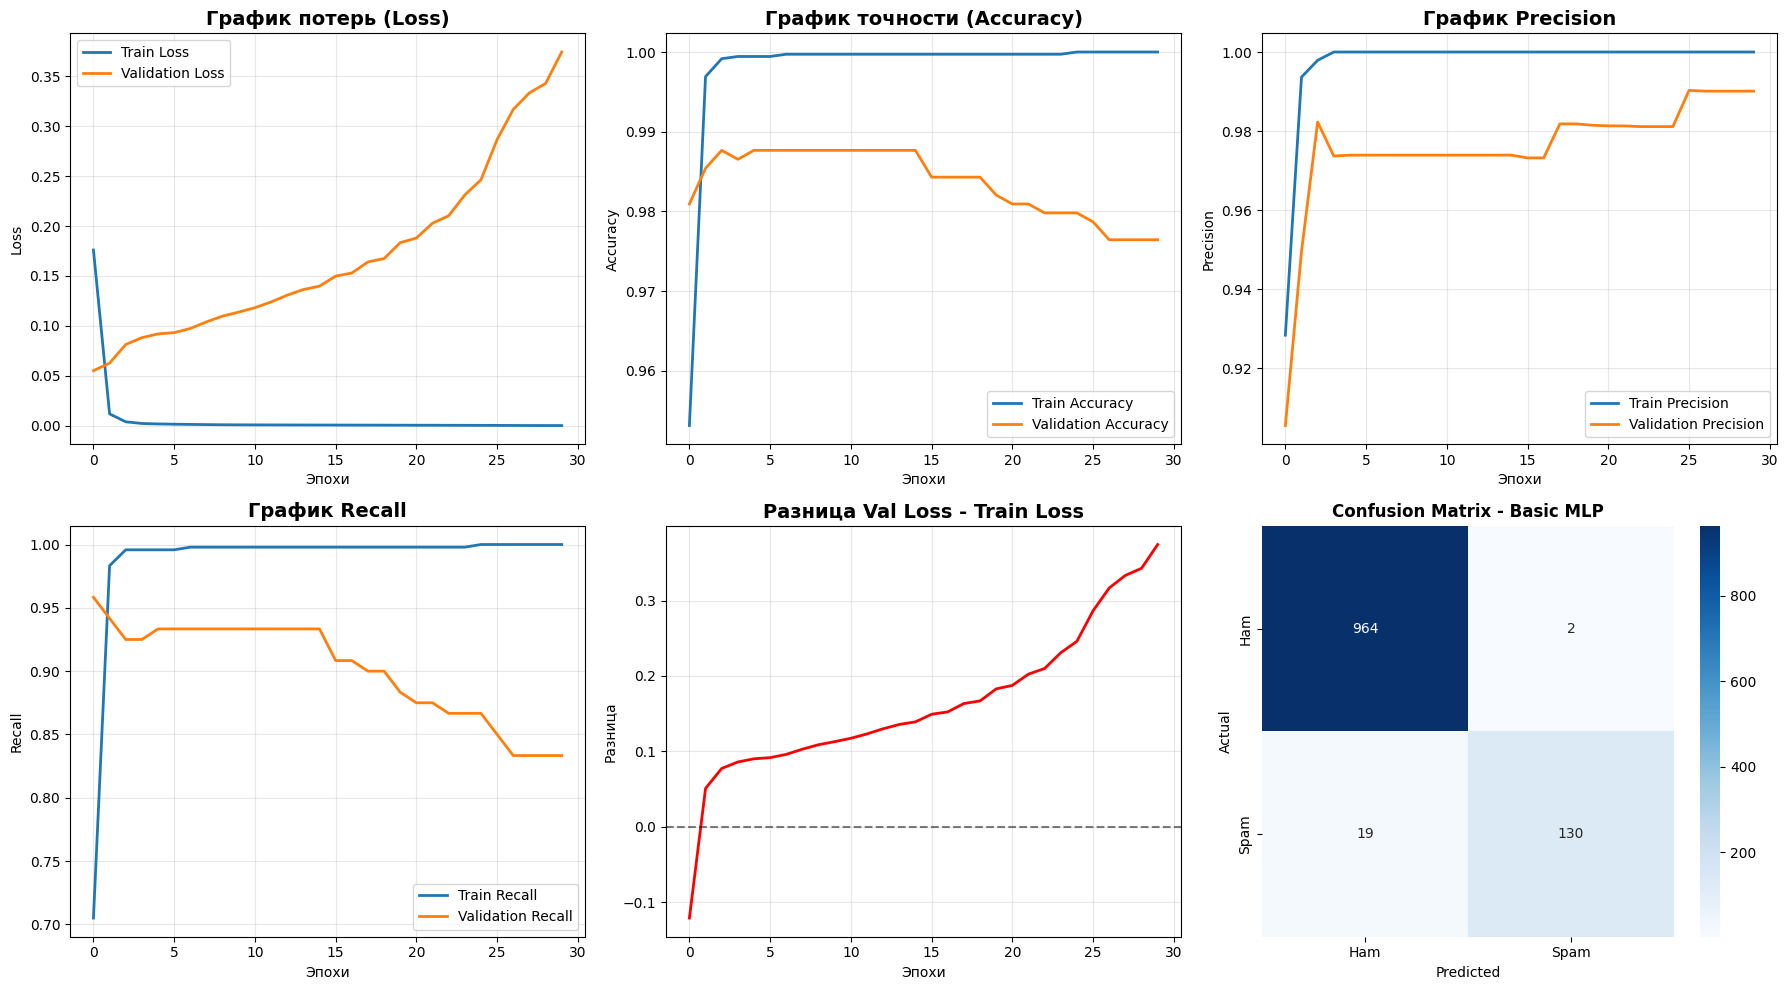

Средний Train loss (последние 5 эпох): 0.0002
Средний Val loss (последние 5 эпох): 0.3309
Разница: 0.3307
Есть признаки переобучения. Нужна регуляризация.


In [41]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# 1. График потерь (Loss)
axes[0, 0].plot(history_basic.history['loss'], label='Train Loss', linewidth=2)
axes[0, 0].plot(history_basic.history['val_loss'], label='Validation Loss', linewidth=2)
axes[0, 0].set_title('График потерь (Loss)', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Эпохи')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# 2. График точности (Accuracy)
axes[0, 1].plot(history_basic.history['accuracy'], label='Train Accuracy', linewidth=2)
axes[0, 1].plot(history_basic.history['val_accuracy'], label='Validation Accuracy', linewidth=2)
axes[0, 1].set_title('График точности (Accuracy)', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('Эпохи')
axes[0, 1].set_ylabel('Accuracy')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# 3. График Precision
axes[0, 2].plot(history_basic.history['precision'], label='Train Precision', linewidth=2)
axes[0, 2].plot(history_basic.history['val_precision'], label='Validation Precision', linewidth=2)
axes[0, 2].set_title('График Precision', fontsize=14, fontweight='bold')
axes[0, 2].set_xlabel('Эпохи')
axes[0, 2].set_ylabel('Precision')
axes[0, 2].legend()
axes[0, 2].grid(True, alpha=0.3)

# 4. График Recall
axes[1, 0].plot(history_basic.history['recall'], label='Train Recall', linewidth=2)
axes[1, 0].plot(history_basic.history['val_recall'], label='Validation Recall', linewidth=2)
axes[1, 0].set_title('График Recall', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('Эпохи')
axes[1, 0].set_ylabel('Recall')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# 5. Разница между train и val loss (переобучение)
axes[1, 1].plot(np.array(history_basic.history['val_loss']) - np.array(history_basic.history['loss']), 
                color='red', linewidth=2)
axes[1, 1].axhline(y=0, color='black', linestyle='--', alpha=0.5)
axes[1, 1].set_title('Разница Val Loss - Train Loss', fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel('Эпохи')
axes[1, 1].set_ylabel('Разница')
axes[1, 1].grid(True, alpha=0.3)

# 6. Confusion Matrix для базовой модели
cm_basic = confusion_matrix(y_test, y_pred_basic)
sns.heatmap(cm_basic, annot=True, fmt='d', cmap='Blues', ax=axes[1, 2],
            xticklabels=['Ham', 'Spam'], yticklabels=['Ham', 'Spam'])
axes[1, 2].set_title('Confusion Matrix - Basic MLP', fontweight='bold')
axes[1, 2].set_ylabel('Actual')
axes[1, 2].set_xlabel('Predicted')

plt.tight_layout()
plt.show()

# Анализ переобучения
last_epochs = 5
train_loss_last = np.mean(history_basic.history['loss'][-last_epochs:])
val_loss_last = np.mean(history_basic.history['val_loss'][-last_epochs:])
print(f"Средний Train loss (последние {last_epochs} эпох): {train_loss_last:.4f}")
print(f"Средний Val loss (последние {last_epochs} эпох): {val_loss_last:.4f}")
print(f"Разница: {val_loss_last - train_loss_last:.4f}")

if val_loss_last - train_loss_last > 0.1:
    print("Есть признаки переобучения. Нужна регуляризация.")
else:
    print("Переобучения не наблюдается.")

### 4.3. MLP с регуляризацией

In [42]:
def create_regularized_mlp(input_dim):
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(256, activation='relu', 
                    kernel_regularizer=tf.keras.regularizers.l2(0.001),
                    name='hidden1'),
        layers.Dropout(0.3, name='dropout1'),
        layers.Dense(128, activation='relu',
                    kernel_regularizer=tf.keras.regularizers.l2(0.001),
                    name='hidden2'),
        layers.Dropout(0.2, name='dropout2'),
        layers.Dense(64, activation='relu',
                    kernel_regularizer=tf.keras.regularizers.l2(0.001),
                    name='hidden3'),
        layers.Dense(1, activation='sigmoid', name='output')
    ])
    
    return model

reg_mlp = create_regularized_mlp(input_dim)
reg_mlp.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.Precision(), tf.keras.metrics.Recall()]
)
reg_mlp.summary()

callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        min_lr=0.00001,
        verbose=1
    )
]

history_reg = reg_mlp.fit(
    X_train_scaled, y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=50,  
    batch_size=32,
    callbacks=callbacks,
    verbose=1
)

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ hidden1 (Dense)                 │ (None, 256)            │       579,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout1 (Dropout)              │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout2 (Dropout)              │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden3 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 620,801 (2.37 MB)

 Trainable params: 620,801 (2.37 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
112/112 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.9045 - loss: 0.7903 - precision_1: 0.6837 - recall_1: 0.3698 - val_accuracy: 0.9787 - val_loss: 0.3673 - val_precision_1: 0.8915 - val_recall_1: 0.9583 - learning_rate: 0.0010
Epoch 2/50
112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9931 - loss: 0.3198 - precision_1: 0.9763 - recall_1: 0.9711 - val_accuracy: 0.9854 - val_loss: 0.2801 - val_precision_1: 0.9280 - val_recall_1: 0.9667 - learning_rate: 0.0010
Epoch 3/50
112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9991 - loss: 0.2245 - precision_1: 0.9990 - recall_1: 0.9945 - val_accuracy: 0.9809 - val_loss: 0.2320 - val_precision_1: 0.8931 - val_recall_1: 0.9750 - learning_rate: 0.0010
Epoch 4/50
112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9985 - loss: 0.1679 - precision_1: 0.9888 - recall_1: 0.9996 - val_accuracy: 0.9865 - val_loss: 0.1762 - val_precision_1: 0.9286 - val_recall_1: 0.9750 - learning_rate: 0.0010
Epoch 5/50
112/112 ━━━━━━━━━

In [43]:
# Оценка на тестовых данных
y_pred_reg = (reg_mlp.predict(X_test_scaled) > 0.5).astype(int)

print("\n Результаты MLP с регуляризацией на тестовых данных")
print(f"Accuracy:  {accuracy_score(y_test, y_pred_reg):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_reg):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_reg):.4f}")
print(f"F1-score:  {f1_score(y_test, y_pred_reg):.4f}")

35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step

 Результаты MLP с регуляризацией на тестовых данных
Accuracy:  0.9848
Precision: 0.9583
Recall:    0.9262
F1-score:  0.9420


### 4.4. Сравнение MLP с регуляризацией и без

In [44]:
print("\nРезультаты базовой MLP модели на тестовой выборке")
print(f"Accuracy:  {accuracy_score(y_test, y_pred_basic):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_basic):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_basic):.4f}")
print(f"F1-score:  {f1_score(y_test, y_pred_basic):.4f}")

print("\nРезультаты MLP с регуляризацией на тестовых данных")
print(f"Accuracy:  {accuracy_score(y_test, y_pred_reg):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_reg):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_reg):.4f}")
print(f"F1-score:  {f1_score(y_test, y_pred_reg):.4f}")


Результаты базовой MLP модели на тестовой выборке
Accuracy:  0.9812
Precision: 0.9848
Recall:    0.8725
F1-score:  0.9253

Результаты MLP с регуляризацией на тестовых данных
Accuracy:  0.9848
Precision: 0.9583
Recall:    0.9262
F1-score:  0.9420


Вывод по MLP: Модель с регуляризацией показала более хорошие результаты, чем модель без регуляризации, F1-score метрика выше, Recall - +7%, что значит модель лучше распознает спам.

## 5. Сравнение всех моделей - MLP и классических

                      Model           Type  Accuracy  Precision  Recall  F1 Score  TP  FP  FN  TN
Logistic Regression (Tuned)         Linear    0.9874     0.9927  0.9128    0.9510 136   1  13 965
          MLP (Regularized) Neural Network    0.9848     0.9583  0.9262    0.9420 138   6  11 960
      Random Forest (Tuned)     Tree-based    0.9821     0.9574  0.9060    0.9310 135   6  14 960
  Gradient Boosting (Tuned)       Ensemble    0.9812     0.9444  0.9128    0.9283 136   8  13 958
                MLP (Basic) Neural Network    0.9812     0.9848  0.8725    0.9253 130   2  19 964


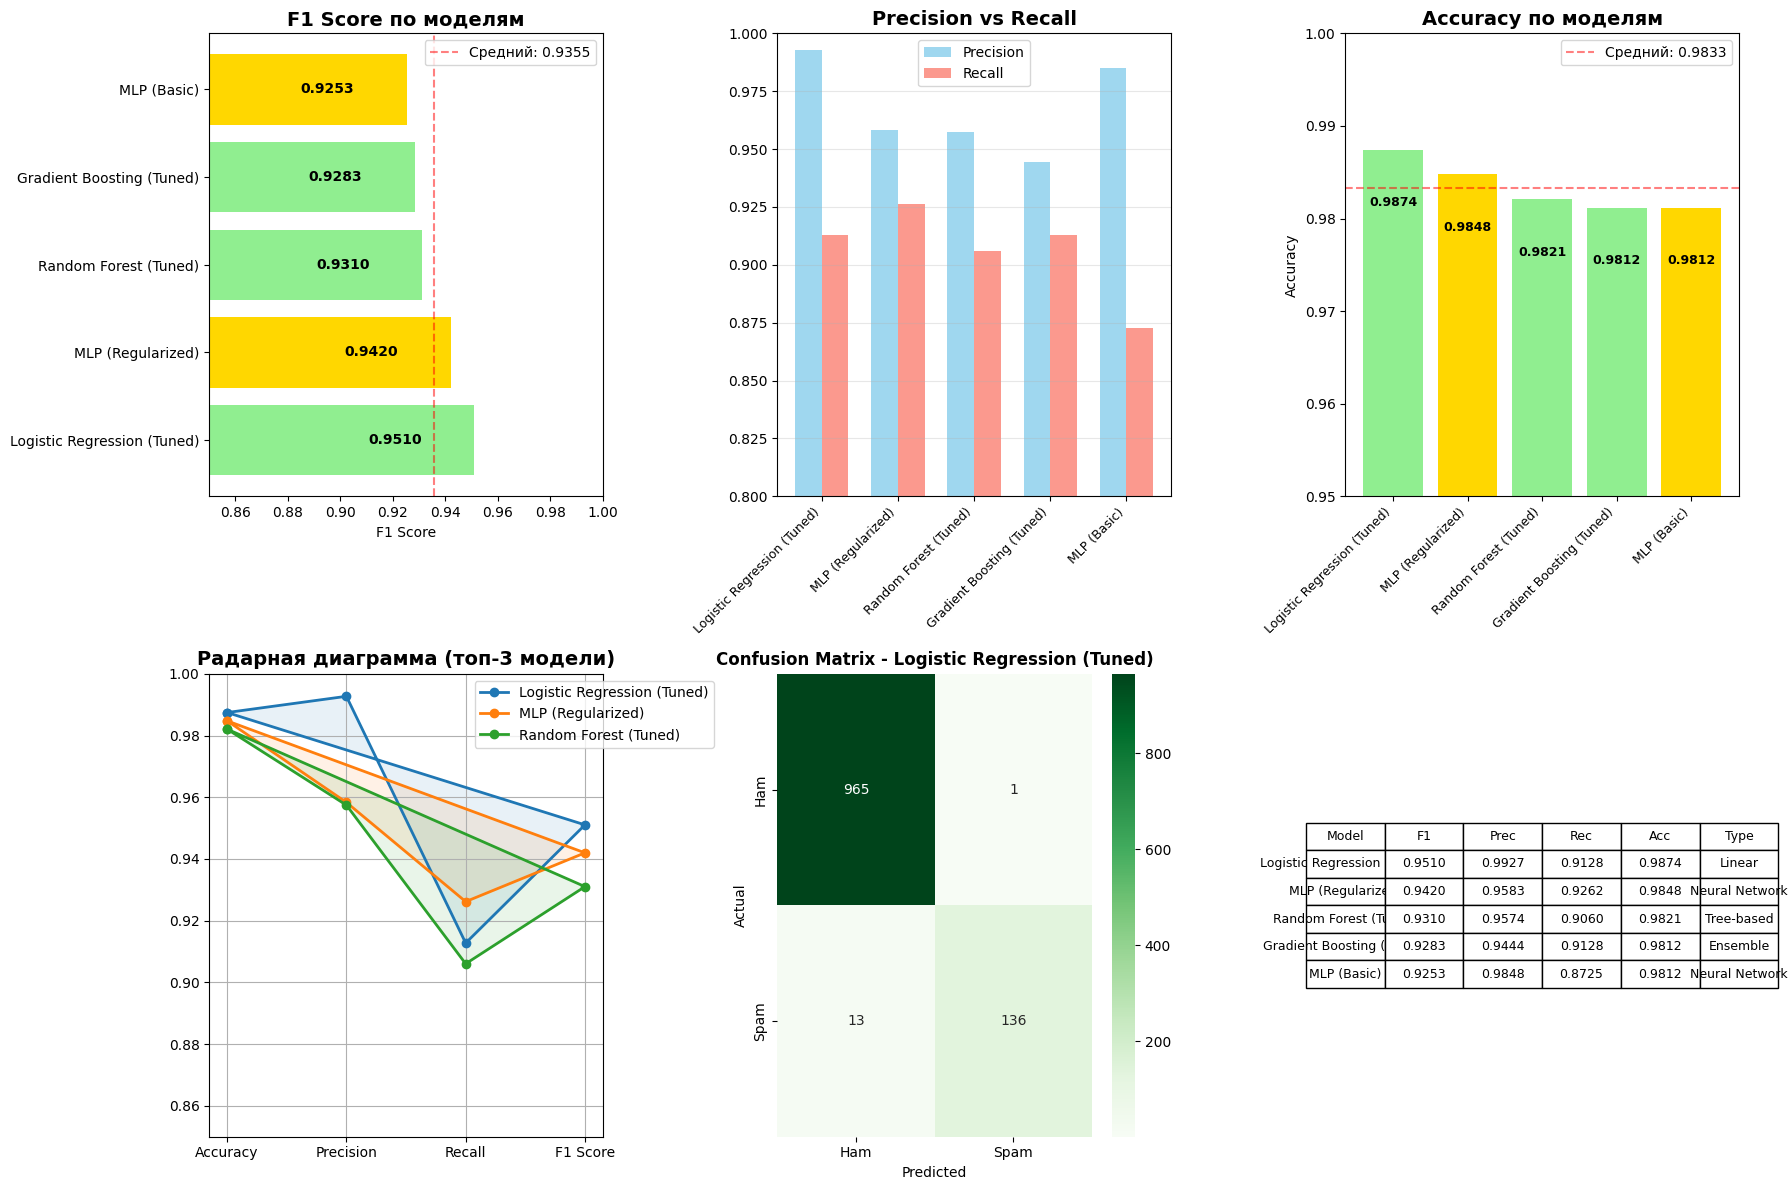

 ЛУЧШАЯ МОДЕЛЬ: Logistic Regression (Tuned)
   - F1 Score: 0.9510
   - Precision: 0.9927
   - Recall: 0.9128
   - Accuracy: 0.9874
   - TP (найдено спама): 136
   - FN (пропущено спама): 13


In [47]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

results = []

# Random Forest (Tuned)
try:
    y_pred_rf = grid_rf.predict(X_test)
    results.append({
        'Model': 'Random Forest (Tuned)',
        'Type': 'Tree-based',
        'Accuracy': accuracy_score(y_test, y_pred_rf),
        'Precision': precision_score(y_test, y_pred_rf),
        'Recall': recall_score(y_test, y_pred_rf),
        'F1 Score': f1_score(y_test, y_pred_rf),
        'TP': confusion_matrix(y_test, y_pred_rf)[1,1],
        'FP': confusion_matrix(y_test, y_pred_rf)[0,1],
        'FN': confusion_matrix(y_test, y_pred_rf)[1,0],
        'TN': confusion_matrix(y_test, y_pred_rf)[0,0]
    })
except:
    print("Random Forest не найдена")

# Logistic Regression (Tuned)
try:
    y_pred_lr_tuned = grid_lr.predict(X_test)
    results.append({
        'Model': 'Logistic Regression (Tuned)',
        'Type': 'Linear',
        'Accuracy': accuracy_score(y_test, y_pred_lr_tuned),
        'Precision': precision_score(y_test, y_pred_lr_tuned),
        'Recall': recall_score(y_test, y_pred_lr_tuned),
        'F1 Score': f1_score(y_test, y_pred_lr_tuned),
        'TP': confusion_matrix(y_test, y_pred_lr_tuned)[1,1],
        'FP': confusion_matrix(y_test, y_pred_lr_tuned)[0,1],
        'FN': confusion_matrix(y_test, y_pred_lr_tuned)[1,0],
        'TN': confusion_matrix(y_test, y_pred_lr_tuned)[0,0]
    })
except:
    print("Logistic Regression Tuned не найдена")

# Gradient Boosting (Tuned)
try:
    y_pred_gb = random_gb.predict(X_test)
    results.append({
        'Model': 'Gradient Boosting (Tuned)',
        'Type': 'Ensemble',
        'Accuracy': accuracy_score(y_test, y_pred_gb),
        'Precision': precision_score(y_test, y_pred_gb),
        'Recall': recall_score(y_test, y_pred_gb),
        'F1 Score': f1_score(y_test, y_pred_gb),
        'TP': confusion_matrix(y_test, y_pred_gb)[1,1],
        'FP': confusion_matrix(y_test, y_pred_gb)[0,1],
        'FN': confusion_matrix(y_test, y_pred_gb)[1,0],
        'TN': confusion_matrix(y_test, y_pred_gb)[0,0]
    })
except:
    print("Gradient Boosting не найдена")

# Basic MLP
try:
    results.append({
        'Model': 'MLP (Basic)',
        'Type': 'Neural Network',
        'Accuracy': accuracy_score(y_test, y_pred_basic),
        'Precision': precision_score(y_test, y_pred_basic),
        'Recall': recall_score(y_test, y_pred_basic),
        'F1 Score': f1_score(y_test, y_pred_basic),
        'TP': confusion_matrix(y_test, y_pred_basic)[1,1],
        'FP': confusion_matrix(y_test, y_pred_basic)[0,1],
        'FN': confusion_matrix(y_test, y_pred_basic)[1,0],
        'TN': confusion_matrix(y_test, y_pred_basic)[0,0]
    })
except:
    print("Basic MLP не найдена")

# Regularized MLP
try:
    results.append({
        'Model': 'MLP (Regularized)',
        'Type': 'Neural Network',
        'Accuracy': accuracy_score(y_test, y_pred_reg),
        'Precision': precision_score(y_test, y_pred_reg),
        'Recall': recall_score(y_test, y_pred_reg),
        'F1 Score': f1_score(y_test, y_pred_reg),
        'TP': confusion_matrix(y_test, y_pred_reg)[1,1],
        'FP': confusion_matrix(y_test, y_pred_reg)[0,1],
        'FN': confusion_matrix(y_test, y_pred_reg)[1,0],
        'TN': confusion_matrix(y_test, y_pred_reg)[0,0]
    })
except:
    print("Regularized MLP не найдена")

df_results = pd.DataFrame(results)
df_results = df_results.sort_values('F1 Score', ascending=False).reset_index(drop=True)

display_cols = ['Model', 'Type', 'Accuracy', 'Precision', 'Recall', 'F1 Score', 'TP', 'FP', 'FN', 'TN']
print(df_results[display_cols].round(4).to_string(index=False))

fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# Сравнение F1 Score
ax1 = axes[0, 0]
colors = ['gold' if 'MLP' in x else 'lightblue' if 'Neural' in x else 'lightgreen' for x in df_results['Model']]
bars1 = ax1.barh(df_results['Model'], df_results['F1 Score'], color=colors)
ax1.set_title('F1 Score по моделям', fontsize=14, fontweight='bold')
ax1.set_xlabel('F1 Score')
ax1.set_xlim(0.85, 1.0)
ax1.axvline(x=df_results['F1 Score'].mean(), color='red', linestyle='--', alpha=0.5, label=f'Средний: {df_results["F1 Score"].mean():.4f}')
ax1.legend()
for i, (bar, val) in enumerate(zip(bars1, df_results['F1 Score'])):
    ax1.text(val - 0.02, bar.get_y() + bar.get_height()/2, f'{val:.4f}', 
             va='center', ha='right', fontweight='bold')

# Сравнение Precision и Recall
ax2 = axes[0, 1]
x = np.arange(len(df_results))
width = 0.35
ax2.bar(x - width/2, df_results['Precision'], width, label='Precision', alpha=0.8, color='skyblue')
ax2.bar(x + width/2, df_results['Recall'], width, label='Recall', alpha=0.8, color='salmon')
ax2.set_title('Precision vs Recall', fontsize=14, fontweight='bold')
ax2.set_xticks(x)
ax2.set_xticklabels(df_results['Model'], rotation=45, ha='right', fontsize=9)
ax2.legend()
ax2.set_ylim(0.8, 1.0)
ax2.grid(True, alpha=0.3, axis='y')

# Сравнение Accuracy
ax3 = axes[0, 2]
bars3 = ax3.bar(df_results['Model'], df_results['Accuracy'], color=colors)
ax3.set_title('Accuracy по моделям', fontsize=14, fontweight='bold')
ax3.set_xticklabels(df_results['Model'], rotation=45, ha='right', fontsize=9)
ax3.set_ylabel('Accuracy')
ax3.set_ylim(0.95, 1.0)
ax3.axhline(y=df_results['Accuracy'].mean(), color='red', linestyle='--', alpha=0.5, label=f'Средний: {df_results["Accuracy"].mean():.4f}')
ax3.legend()
for bar, val in zip(bars3, df_results['Accuracy']):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() - 0.005, 
             f'{val:.4f}', ha='center', va='top', fontweight='bold', fontsize=9)

# Радарная диаграмма для топ-3 моделей
ax4 = axes[1, 0]
top3 = df_results.head(3)
metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
angles = np.linspace(0, 2 * np.pi, len(metrics), endpoint=False).tolist()
angles += angles[:1]

for idx, (_, row) in enumerate(top3.iterrows()):
    values = row[metrics].tolist()
    values += values[:1]
    ax4.plot(angles, values, 'o-', linewidth=2, label=row['Model'])
    ax4.fill(angles, values, alpha=0.1)

ax4.set_xticks(angles[:-1])
ax4.set_xticklabels(metrics, fontsize=10)
ax4.set_ylim(0.85, 1.0)
ax4.set_title('Радарная диаграмма (топ-3 модели)', fontsize=14, fontweight='bold')
ax4.legend(loc='upper right', bbox_to_anchor=(1.3, 1.0))
ax4.grid(True)

# Confusion Matrix для лучшей модели
ax5 = axes[1, 1]
best_model_idx = df_results['F1 Score'].idxmax()
best_model_name = df_results.loc[best_model_idx, 'Model']
best_model_cm = np.array([[df_results.loc[best_model_idx, 'TN'], df_results.loc[best_model_idx, 'FP']],
                          [df_results.loc[best_model_idx, 'FN'], df_results.loc[best_model_idx, 'TP']]])

sns.heatmap(best_model_cm, annot=True, fmt='d', cmap='Greens', ax=ax5,
            xticklabels=['Ham', 'Spam'], yticklabels=['Ham', 'Spam'])
ax5.set_title(f'Confusion Matrix - {best_model_name}', fontweight='bold')
ax5.set_ylabel('Actual')
ax5.set_xlabel('Predicted')

# Сводная таблица
ax6 = axes[1, 2]
ax6.axis('tight')
ax6.axis('off')
table_data = []
for _, row in df_results.iterrows():
    table_data.append([row['Model'], f"{row['F1 Score']:.4f}", 
                       f"{row['Precision']:.4f}", f"{row['Recall']:.4f}", 
                       f"{row['Accuracy']:.4f}", row['Type']])

table = ax6.table(cellText=table_data,
                  colLabels=['Model', 'F1', 'Prec', 'Rec', 'Acc', 'Type'],
                  cellLoc='center', loc='center')
table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1.2, 1.5)

plt.tight_layout()
plt.show()


best_model = df_results.iloc[0]
print(f" ЛУЧШАЯ МОДЕЛЬ: {best_model['Model']}")
print(f"   - F1 Score: {best_model['F1 Score']:.4f}")
print(f"   - Precision: {best_model['Precision']:.4f}")
print(f"   - Recall: {best_model['Recall']:.4f}")
print(f"   - Accuracy: {best_model['Accuracy']:.4f}")
print(f"   - TP (найдено спама): {best_model['TP']}")
print(f"   - FN (пропущено спама): {best_model['FN']}")

## 6. Вывод по моделям

Из всех обученных моделей, классических и MLP, наилучший результат дала модель Логистической регрессии с регуляризацией. Возможные причины, по которым лучший результат дала логистическая регрессия:
- после TF-IDF векторизации данные оказались хорошо линейно разделимыми, спам имеет четкие лексические паттерны
- логистическая регрессия меньше сколнна к переобучению на небольших данных по сравнению со сложными моделями
- подбор гиперпараметров с помощью кросс-валидации позволил найти нужную силу регуляризации

## 7. Исследование наиболее информативных слов

In [48]:
from wordcloud import WordCloud

best_model = grid_lr.best_estimator_
coefficients = best_model.coef_[0]
feature_names = tfidf.get_feature_names_out().tolist() + X_features.columns.tolist()
feature_importance = pd.DataFrame({
    'feature': feature_names,
    'coefficient': coefficients,
    'abs_coefficient': np.abs(coefficients)
})
feature_importance['type'] = ['word'] * len(tfidf.get_feature_names_out()) + \
                             ['numeric'] * len(X_features.columns)

print("Слова, характерные для спама")
spam_words = feature_importance[feature_importance['type'] == 'word'] \
    .sort_values('coefficient', ascending=False).head(20)
for i, (idx, row) in enumerate(spam_words.iterrows(), 1):
    print(f"{i:2d}. {row['feature']:20s} - коэффициент: {row['coefficient']:.4f}")

The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.
Слова, характерные для спама
 1. text                 - коэффициент: 3.7584
 2. free                 - коэффициент: 3.5273
 3. mobile               - коэффициент: 3.4486
 4. uk                   - коэффициент: 3.1753
 5. ringtone             - коэффициент: 2.9869
 6. reply                - коэффициент: 2.9407
 7. new                  - коэффициент: 2.7573
 8. message              - коэффициент: 2.5933
 9. service              - коэффициент: 2.5804
10. enjoy                - коэффициент: 2.5720
11. week                 - коэффициент: 2.4537
12. content              - коэффициент: 2.3973
13. stop                 - коэффициент: 2.2345
14. order                - коэффициент: 2.2018
15. sms                  - коэффициент: 2.0689
16. games                - коэффициент: 2.0585
17. txt                  - коэффициент: 1.7593
18. win           

## Вывод

В ходе выполнения проекта была решена задачи классификации SMS-сообщений на спам и не спам с использованием методов машинного обучения. На основе датасета SMS Spam Collection было проведено полное исследование, включающее этапы предобработки данных, создание новых признаков (длина сообщения, количество заглавных букв, наличие url и телефонов), векторизации текста с помощью TF-IDF, а также обучения и сравнения различных моделей: Логистическая регрессия, Random Forest, Gradient Boosting, MLP с регуляризацией и без. Наилучший результат показала логистическая регрессия с подобранными гиперпараметрами, достигнув F1-score = 0.951 на тестовой выборке. Классическая модель превзошла более сложные алгоритмы и нейросети, что объясняется хорошей линейной разделимостью данных, небольшим объемом выборки и эффективной регуляризацией.